<a href="https://colab.research.google.com/github/mihreteab-ak/andriod-studio/blob/main/SolarGenUNISOLAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solar Power Prediction with Advanced Feature Engineering, Feature Reduction and Multisite Validation

### Google Drive Integration

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Install Required Libraries


In [3]:
!pip install pvlib
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 4.0 MB/s eta 0:00:00


### Import Libraries

In [4]:
import pandas as pd
import numpy as np
import pvlib
import warnings
import optuna
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import time
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# Silence warnings for a clean output
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

### Load and Resample Data


In [5]:
print("Loading and resampling data to HOURLY intervals...")
path = '/content/drive/MyDrive/UNISOLAR_Data/'

gen_df = pd.read_csv(path + 'Solar_Energy_Generation.csv', parse_dates=['Timestamp'])
weather_df = pd.read_csv(path + 'Weather_Data_reordered_all.csv', parse_dates=['Timestamp'])
site_df = pd.read_csv(path + 'Solar_Site_Details.csv')

# Merge datasets
df = gen_df.merge(weather_df, on=['CampusKey', 'Timestamp'], how='inner')
df = df.merge(site_df[['CampusKey', 'SiteKey', 'lat', 'Lon']], on=['CampusKey', 'SiteKey'], how='left')

# Isolate Campus 1
target_site_df = df[(df['CampusKey'] == 2) & (df['SiteKey'] == 1)].copy()
target_site_df = target_site_df.sort_values('Timestamp')

# Resample
target_site_df.set_index('Timestamp', inplace=True)
hourly_df = target_site_df.resample('1h').mean()
hourly_df['SolarGeneration']= hourly_df['SolarGeneration'] * 4
hourly_df.reset_index(inplace=True)

# Interpolate
weather_cols = ['ApparentTemperature', 'AirTemperature', 'RelativeHumidity', 'WindSpeed']
hourly_df[weather_cols] = hourly_df[weather_cols].interpolate(method='linear').ffill().bfill()

hourly_df.shape

hourly_df_weather = hourly_df.copy()
hourly_df_weather = hourly_df_weather.dropna(subset=['SolarGeneration'])

Loading and resampling data to HOURLY intervals...


### Analyze Maximum Power Output per Site


In [6]:
site_max_power = df.groupby(['CampusKey', 'SiteKey'])['SolarGeneration'].max().reset_index()
site_max_power.columns = ['CampusKey', 'SiteKey', 'Max_Power_Output_kW']
site_max_power = site_max_power.sort_values(by='Max_Power_Output_kW', ascending=False)

site_df.columns

print("Maximum Power Output per Site:")
display(site_max_power)

Maximum Power Output per Site:


,CampusKey,SiteKey,Max_Power_Output_kW
13,1,27,99.218800
37,3,11,92.750000
11,1,25,80.250000
5,1,19,42.218750
4,1,18,35.312500
32,3,6,28.734375
34,3,8,26.968750
40,4,41,21.937500
27,2,1,21.778000
19,1,33,18.851562


### Environment and Library Version Check

In [7]:
import sys
import sklearn
import xgboost as xgb
import lightgbm as lgb
import optuna
import pandas as pd
import numpy as np

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"XGBoost: {xgb.__version__}")
print(f"LightGBM: {lgb.__version__}")
print(f"Optuna: {optuna.__version__}")

Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.2.2
Scikit-learn: 1.6.1
XGBoost: 3.2.0
LightGBM: 4.6.0
Optuna: 4.9.0


### System Hardware Information

In [8]:
# CPU info
!cat /proc/cpuinfo | grep "model name" | head -1

# RAM
!grep MemTotal /proc/meminfo

model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
MemTotal:       13286936 kB


### Distribution of Hourly Solar Generation


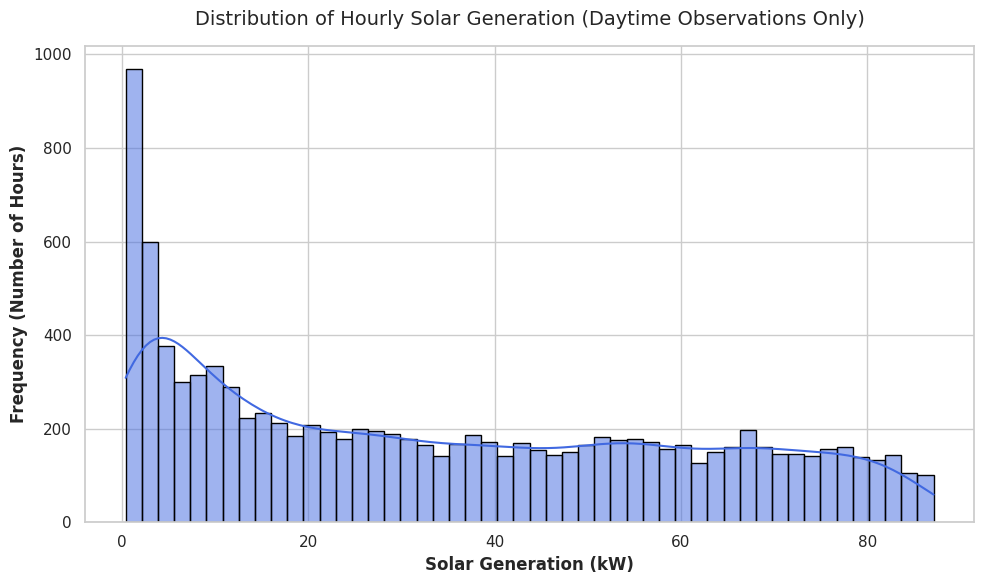

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(data=hourly_df_weather, x='SolarGeneration', bins=50, kde=True, color='royalblue', edgecolor='black')

plt.title('Distribution of Hourly Solar Generation (Daytime Observations Only)', fontsize=14, pad=15)
plt.xlabel('Solar Generation (kW)', fontsize=12, weight='bold')
plt.ylabel('Frequency (Number of Hours)', fontsize=12, weight='bold')

plt.tight_layout()

plt.savefig('Solar_Generation_Histogram.png', dpi=300, bbox_inches='tight')

plt.show()

In [10]:
features = [
    'ApparentTemperature', 'AirTemperature', 'DewPointTemperature',
    'RelativeHumidity', 'WindSpeed', 'WindDirection', 'hour'
]

hourly_df_weather['hour'] = hourly_df_weather['Timestamp'].dt.hour

X = hourly_df_weather[features]
y = hourly_df_weather['SolarGeneration']

# Chronological Split (80/20)
split = int(len(hourly_df_weather) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Data successfully processed! Training on {len(X_train)} HOURLY rows with {len(features)} features.")

y_test.shape


Data successfully processed! Training on 8266 HOURLY rows with 7 features.


(2067,)

### Check for Missing Values


In [11]:
hourly_df_weather.isna().sum()

,0
Timestamp,0
CampusKey,0
SiteKey,0
SolarGeneration,0
ApparentTemperature,0
AirTemperature,0
DewPointTemperature,50
RelativeHumidity,0
WindSpeed,0
WindDirection,3489


### Advanced Feature Engineering.

In [12]:
import pvlib

print("Engineering 7-day lag, 3D astrophysics, and weather interactions...")

# The 7-Day Memory
LAG_STEPS = 168
hourly_df['lag_7_days'] = hourly_df['SolarGeneration'].shift(LAG_STEPS)
hourly_df['weekly_trend'] = hourly_df['SolarGeneration'].shift(LAG_STEPS).rolling(window=24, min_periods=1).mean()

# Physics & 3D Sun Position
tz = 'Australia/Melbourne'
lat, lon = hourly_df['lat'].iloc[0], hourly_df['Lon'].iloc[0]
location = pvlib.location.Location(lat, lon, tz=tz)
times = pd.DatetimeIndex(hourly_df['Timestamp'])

if times.tz is None:
    times = times.tz_localize(tz, ambiguous='NaT', nonexistent='NaT')

hourly_df['Theoretical_Max_GHI'] = location.get_clearsky(times)['ghi'].values
solar_position = location.get_solarposition(times)
hourly_df['zenith'] = solar_position['zenith'].values
hourly_df['azimuth'] = solar_position['azimuth'].values

# Weather Interactions
hourly_df['Temp_Gradient'] = hourly_df['AirTemperature'].diff()
hourly_df['Temp_Squared'] = hourly_df['AirTemperature'] ** 2  # Models panel heat degradation
hourly_df['Temp_Humidity_Interact'] = hourly_df['AirTemperature'] * hourly_df['RelativeHumidity']
hourly_df['Wind_Temp_Interact'] = hourly_df['WindSpeed'] * hourly_df['AirTemperature']
hourly_df['temp_ma_24h'] = hourly_df['AirTemperature'].rolling(window=24, min_periods=1).mean()
hourly_df['humidity_ma_6h'] = hourly_df['RelativeHumidity'].rolling(window=6, min_periods=1).mean()
hourly_df['windspeed_ma_3h'] = hourly_df['WindSpeed'].rolling(window=3, min_periods=1).mean()

# Temporal
hourly_df['hour_sin'] = np.sin(2 * np.pi * hourly_df['Timestamp'].dt.hour/24)
hourly_df['hour_cos'] = np.cos(2 * np.pi * hourly_df['Timestamp'].dt.hour/24)
hourly_df['month_sin'] = np.sin(2 * np.pi * hourly_df['Timestamp'].dt.month/12)
hourly_df['month_cos'] = np.cos(2 * np.pi * hourly_df['Timestamp'].dt.month/12)
hourly_df['day_of_year'] = hourly_df['Timestamp'].dt.dayofyear
hourly_df['is_weekend'] = hourly_df['Timestamp'].dt.dayofweek.isin([5, 6]).astype(int)

# Drop Nans
df_final = hourly_df.iloc[LAG_STEPS:].reset_index(drop=True)
df_final = df_final.dropna(subset=["SolarGeneration"])
features = [
    'ApparentTemperature', 'AirTemperature', 'DewPointTemperature',
    'RelativeHumidity', 'WindSpeed', 'WindDirection',
    'Theoretical_Max_GHI', 'zenith', 'azimuth',
    'Temp_Gradient', 'Temp_Squared', 'Temp_Humidity_Interact', 'Wind_Temp_Interact',
    'temp_ma_24h', 'humidity_ma_6h', 'windspeed_ma_3h',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_year', 'is_weekend',
    'lag_7_days', 'weekly_trend'
]

X = df_final[features]
y = df_final['SolarGeneration']

# Chronological Split 80/20
split = int(len(df_final) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Data successfully processed! Training on {len(X_train)} HOURLY rows with {len(features)} features.")
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("Initializing final models with deep-optimized parameters...\n")

# Dataset 1: Weather Baseline (7 Features)
base_features = [
    'ApparentTemperature', 'AirTemperature', 'DewPointTemperature',
    'RelativeHumidity', 'WindSpeed', 'WindDirection', 'hour'
]
X_base = hourly_df_weather[base_features]
y_base = hourly_df_weather['SolarGeneration']

split_base = int(len(hourly_df_weather) * 0.8)
X_train_base, X_test_base = X_base.iloc[:split_base], X_base.iloc[split_base:]
y_train_base, y_test_base = y_base.iloc[:split_base], y_base.iloc[split_base:]
global_range_base = y_base.max() - y_base.min()

# Dataset 2: Engineered (All Advanced Features)
eng_features = [
    'ApparentTemperature', 'AirTemperature', 'DewPointTemperature',
    'RelativeHumidity', 'WindSpeed', 'WindDirection',
    'Theoretical_Max_GHI', 'zenith', 'azimuth',
    'Temp_Gradient', 'Temp_Squared', 'Temp_Humidity_Interact', 'Wind_Temp_Interact',
    'temp_ma_24h', 'humidity_ma_6h', 'windspeed_ma_3h',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_year', 'is_weekend',
    'lag_7_days', 'weekly_trend'
]
X_eng = df_final[eng_features]
y_eng = df_final['SolarGeneration']

split_eng = int(len(df_final) * 0.8)
X_train_eng, X_test_eng = X_eng.iloc[:split_eng], X_eng.iloc[split_eng:]
y_train_eng, y_test_eng = y_eng.iloc[:split_eng], y_eng.iloc[split_eng:]
global_range_eng = y_eng.max() - y_eng.min()


Engineering 7-day lag, 3D astrophysics, and weather interactions...
Data successfully processed! Training on 8184 HOURLY rows with 24 features.
Initializing final models with deep-optimized parameters...



### Model Optimization and Training Function

In [ ]:
import time
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import optuna

def optimize_and_train(X_train, y_train, X_test, y_test, model_name, n_trials=100):
    """
    Optimizes a model using Optuna on T4 GPU and returns:
    1. A dictionary of metrics and parameters
    2. The actual trained model object
    """

    def objective(trial):
        tscv = TimeSeriesSplit(n_splits=3)
        rmse_scores = []

        if model_name == 'XGBoost':
            param = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'gamma': trial.suggest_float('gamma', 0, 5.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
                'tree_method': 'hist',
                'random_state': 42
            }
            model = xgb.XGBRegressor(**param)

        elif model_name == 'LightGBM':
            param = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
                'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
                'num_leaves': trial.suggest_int('num_leaves', 20, 300),
                'max_depth': trial.suggest_int('max_depth', -1, 15),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
                'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
                'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
                'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
                'verbose': -1,
                'random_state': 42
            }
            model = lgb.LGBMRegressor(**param)

        elif model_name == 'RandomForest':
            param = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
                'max_depth': trial.suggest_int('max_depth', 3, 20),
                'max_features': trial.suggest_float('max_features', 0.5, 1.0),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                'max_samples': trial.suggest_float('max_samples', 0.5, 1.0),
                'random_state': 42
            }

            model = RandomForestRegressor(**param, n_jobs=-1)

        for train_idx, val_idx in tscv.split(X_train):
            model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
            preds = model.predict(X_train.iloc[val_idx])
            rmse_scores.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], preds)))

        current_rmse = np.mean(rmse_scores)
        if (trial.number + 1) % 10 == 0:
            print(f"  [{model_name}] Trial {trial.number + 1}/{n_trials} complete | RMSE:{current_rmse}")

        return current_rmse

    # Execute Optuna
    start_time = time.time()
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)

    # Best Params
    best_params = study.best_params

    # Train Final Best Model Object
    if model_name == 'XGBoost':
        best_model = xgb.XGBRegressor(**best_params, tree_method='hist', random_state=42)
    elif model_name == 'LightGBM':
        best_model = lgb.LGBMRegressor(**best_params, random_state=42, verbose=-1)
    else:
        best_model = RandomForestRegressor(**best_params, n_jobs=-1, random_state=42)

    best_model.fit(X_train, y_train)

    # Metrics
    final_preds = np.maximum(0, best_model.predict(X_test))
    r2 = r2_score(y_test, final_preds)
    rmse = np.sqrt(mean_squared_error(y_test, final_preds))
    run_time = round(time.time() - start_time, 2)

    print(f"  -> [{model_name} SUCCESS] R2: {r2:.4f} | Time: {run_time}s")

    res_data = {
        'Model': model_name,
        'R2': r2,
        'RMSE': rmse,
        'Time_sec': run_time,
        'Best_Params': best_params
    }

    return res_data, best_model

### Weather Baseline Model Experiment


In [13]:
experiment_results = []
trained_models = {}

models_to_test = ['XGBoost', 'LightGBM', 'RandomForest']

print("Weather Only Baseline")

for model_name in models_to_test:
    res, model_obj = optimize_and_train(X_train_base, y_train_base, X_test_base, y_test_base, model_name=model_name, n_trials=100)
    res['Feature_Set'] = 'Weather_Only'
    experiment_results.append(res)
    trained_models[f"{model_name}_Weather_Only"] = model_obj

Weather Only Baseline
  [XGBoost] Trial 10/100 complete | RMSE:14.934378405913554
  [XGBoost] Trial 20/100 complete | RMSE:14.186582420443925
  [XGBoost] Trial 30/100 complete | RMSE:14.51708172614997
  [XGBoost] Trial 40/100 complete | RMSE:14.311337667586946
  [XGBoost] Trial 50/100 complete | RMSE:16.503076400926236
  [XGBoost] Trial 60/100 complete | RMSE:14.094838764202388
  [XGBoost] Trial 70/100 complete | RMSE:14.579182284995056
  [XGBoost] Trial 80/100 complete | RMSE:15.11445977644327
  [XGBoost] Trial 90/100 complete | RMSE:14.191419472836957
  [XGBoost] Trial 100/100 complete | RMSE:14.246465168835961
  -> [XGBoost SUCCESS] R2: 0.7838 | Time: 284.84s
  [LightGBM] Trial 10/100 complete | RMSE:14.775328109070111
  [LightGBM] Trial 20/100 complete | RMSE:19.410277273296657
  [LightGBM] Trial 30/100 complete | RMSE:13.557130517527485
  [LightGBM] Trial 40/100 complete | RMSE:18.66031848450271
  [LightGBM] Trial 50/100 complete | RMSE:13.617047530736306
  [LightGBM] Trial 60/100

### Engineered Model Experiment





In [17]:
models_to_test = ['XGBoost', 'LightGBM', 'RandomForest']

print("Engineered")

for model_name in models_to_test:
    res, model_obj = optimize_and_train(X_train_eng, y_train_eng, X_test_eng, y_test_eng, model_name=model_name, n_trials=100)
    res['Feature_Set'] = 'Engineered'
    experiment_results.append(res)
    trained_models[f"{model_name}_Engineered"] = model_obj

Engineered
  [XGBoost] Trial 10/100 complete | RMSE:10.355937172045452
  [XGBoost] Trial 20/100 complete | RMSE:10.501642253744924
  [XGBoost] Trial 30/100 complete | RMSE:10.364751820126552
  [XGBoost] Trial 40/100 complete | RMSE:10.015140913075745
  [XGBoost] Trial 50/100 complete | RMSE:12.034856818278792
  [XGBoost] Trial 60/100 complete | RMSE:10.003788903260435
  [XGBoost] Trial 70/100 complete | RMSE:10.027401827723981
  [XGBoost] Trial 80/100 complete | RMSE:10.054742314408545
  [XGBoost] Trial 90/100 complete | RMSE:10.04311608543626
  [XGBoost] Trial 100/100 complete | RMSE:10.232757017093652
  -> [XGBoost SUCCESS] R2: 0.8815 | Time: 667.61s
  [LightGBM] Trial 10/100 complete | RMSE:10.77826627143503
  [LightGBM] Trial 20/100 complete | RMSE:9.946315346605608
  [LightGBM] Trial 30/100 complete | RMSE:11.961404418454173
  [LightGBM] Trial 40/100 complete | RMSE:10.392097480216917
  [LightGBM] Trial 50/100 complete | RMSE:10.22054142133264
  [LightGBM] Trial 60/100 complete | 

In [18]:
import pprint

pprint.pprint(experiment_results)

[{'Model': 'XGBoost', 'R2': 0.7838128947334013, 'RMSE': np.float64(12.982641601648789), 'Time_sec': 284.84, 'Best_Params': {'n_estimators': 552, 'max_depth': 4, 'learning_rate': 0.006497504065769695, 'subsample': 0.8828907346041621, 'colsample_bytree': 0.9158455282262367, 'gamma': 3.878111634415527, 'reg_alpha': 0.029541492043102507, 'reg_lambda': 1.853024491161893e-08}, 'Feature_Set': 'Weather_Only'}, {'Model': 'LightGBM', 'R2': 0.7855640063174159, 'RMSE': np.float64(12.929955115507612), 'Time_sec': 174.3, 'Best_Params': {'n_estimators': 590, 'learning_rate': 0.00501419686091862, 'num_leaves': 252, 'max_depth': -1, 'min_child_samples': 50, 'feature_fraction': 0.944374590240012, 'bagging_fraction': 0.7433422177135989, 'bagging_freq': 6}, 'Feature_Set': 'Weather_Only'}, {'Model': 'RandomForest', 'R2': 0.7843753267990946, 'RMSE': np.float64(12.96574279254525), 'Time_sec': 1490.94, 'Best_Params': {'n_estimators': 569, 'max_depth': 13, 'max_features': 0.9549013950360257, 'min_samples_split

### Comparative Model Training and Performance Evaluation


In [23]:
import time
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


feature_sets = {
    "Baseline":   (X_train_base, y_train_base, X_test_base, y_test_base, global_range_base),
    "Engineered": (X_train_eng,  y_train_eng,  X_test_eng,  y_test_eng,  global_range_eng),
}

model_configs = {
    "XGBoost": {
        "Baseline":   XGBRegressor(n_estimators=322, max_depth=4,  learning_rate=0.010342, subsample=0.835251, colsample_bytree=0.934301, min_child_weight=2, reg_alpha=0.004610, reg_lambda=0.322259, tree_method="hist", random_state=42),
        "Engineered": XGBRegressor(n_estimators=563, max_depth=5,  learning_rate=0.007263, subsample=0.672192, colsample_bytree=0.849702, min_child_weight=3, reg_alpha=0.021220, reg_lambda=1.884688, tree_method="hist", random_state=42),
    },
    "LightGBM": {
        "Baseline":   LGBMRegressor(n_estimators=365, learning_rate=0.007931, num_leaves=223, max_depth=7,  min_child_samples=67, feature_fraction=0.827006, bagging_fraction=0.753740, bagging_freq=4, verbose=-1, random_state=42),
        "Engineered": LGBMRegressor(n_estimators=806, learning_rate=0.005117, num_leaves=69,  max_depth=11, min_child_samples=47, feature_fraction=0.631214, bagging_fraction=0.626777, bagging_freq=7, verbose=-1, random_state=42),
    },
    "RandomForest": {
        "Baseline":   RandomForestRegressor(n_estimators=166, max_depth=12, min_samples_split=20, min_samples_leaf=9, max_features=0.947382, max_samples=0.638924, random_state=42, n_jobs=-1),
        "Engineered": RandomForestRegressor(n_estimators=896, max_depth=19, min_samples_split=2,  min_samples_leaf=4, max_features=0.906858, max_samples=0.556654, random_state=42, n_jobs=-1),
    },
}


def evaluate(model, X_tr, y_tr, X_te, y_te, global_range):
    t0 = time.time(); model.fit(X_tr, y_tr); train_time = time.time() - t0
    t0 = time.time(); preds = np.maximum(0, model.predict(X_te)); inf_time = time.time() - t0
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    return {
        "R2":                 r2_score(y_te, preds),
        "RMSE":               rmse,
        "MAE":                mean_absolute_error(y_te, preds),
        "NRMSE (%)":          (rmse / global_range) * 100,
        "Train_Time (s)":     train_time,
        "Inference_Time (s)": inf_time,
    }


results_list = []
for model_name, configs in model_configs.items():
    for fs_name, (X_tr, y_tr, X_te, y_te, gr) in feature_sets.items():
        row = {"Model": model_name, "Feature_Set": fs_name}
        row.update(evaluate(configs[fs_name], X_tr, y_tr, X_te, y_te, gr))
        results_list.append(row)

results_df = pd.DataFrame(results_list)
print(results_df)

          Model Feature_Set        R2       RMSE        MAE  NRMSE (%)  \
0       XGBoost    Baseline  0.778195  13.150236  10.642719  15.166116   
1       XGBoost  Engineered  0.882280   9.600427   6.947903  11.072135   
2      LightGBM    Baseline  0.786741  12.894411  10.272201  14.871074   
3      LightGBM  Engineered  0.871373  10.035316   7.318685  11.573691   
4  RandomForest    Baseline  0.785386  12.935327   9.999091  14.918262   
5  RandomForest  Engineered  0.871999  10.010872   7.188048  11.545500   

   Train_Time (s)  Inference_Time (s)  
0        2.531343            0.016052  
1        2.959426            0.045507  
2        0.843823            0.068355  
3        3.801443            0.307761  
4        7.028038            0.080883  
5      109.359389            0.496890  


### Feature Importance Analysis (XGBoost)


Training final XGBoost model for Feature Importance extraction...


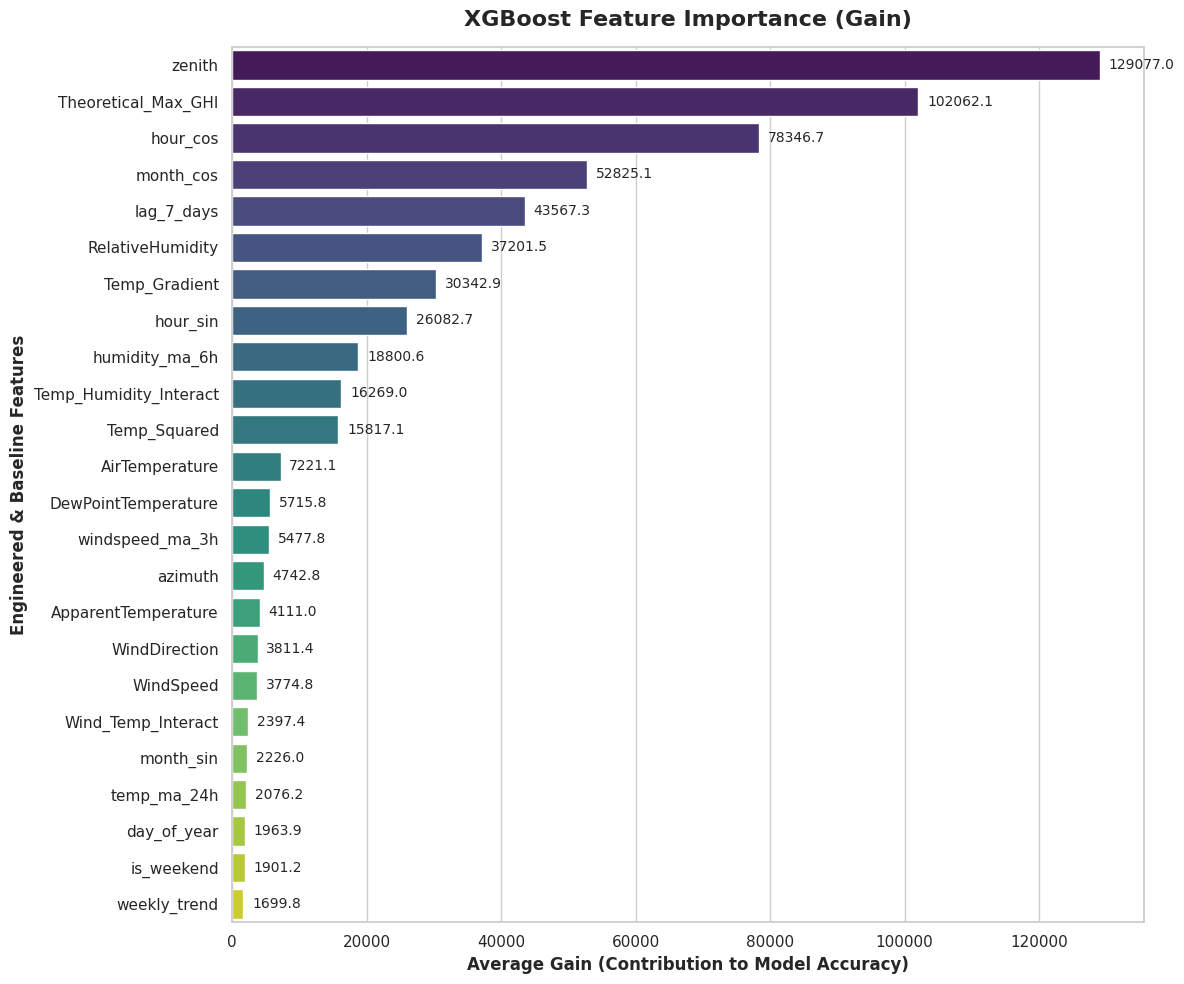

In [24]:
print("Training final XGBoost model for Feature Importance extraction...")

xgb_eng_params = {
    "n_estimators": 807,
    "max_depth": 3,
    "learning_rate": 0.00619738295669263,
    "subsample": 0.7093490495503281,
    "colsample_bytree": 0.5688824136696388,
    "min_child_weight": 9,
    "reg_alpha": 3.6592276331924533e-06,
    "reg_lambda": 0.0026330997540006834
  }

# Initialize and train
best_xgb_eng = xgb.XGBRegressor(**xgb_eng_params, tree_method='hist', random_state=42)
best_xgb_eng.fit(X_train_eng, y_train_eng)

# Extract Feature Importances
importance_dict = best_xgb_eng.get_booster().get_score(importance_type='gain')

importance_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Gain': list(importance_dict.values())
})

importance_df = importance_df.sort_values(by='Gain', ascending=False).reset_index(drop=True)

# Plot
plt.figure(figsize=(12, 10))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x='Gain', y='Feature', data=importance_df, palette='viridis')

plt.title('XGBoost Feature Importance (Gain)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Average Gain (Contribution to Model Accuracy)', fontsize=12, fontweight='bold')
plt.ylabel('Engineered & Baseline Features', fontsize=12, fontweight='bold')

for p in ax.patches:
    width = p.get_width()
    plt.text(width + (importance_df['Gain'].max() * 0.01),
             p.get_y() + p.get_height() / 2,
             f'{width:.1f}',
             va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Recursive Feature Elimination (RFECV)

In [25]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import TimeSeriesSplit

# Initialize
selector = RFECV(
    estimator=xgb.XGBRegressor(**xgb_eng_params, tree_method='hist', device='cuda'),
    step=1,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Run the search
print("Finding the optimal feature subset...")
selector.fit(X_train_eng, y_train_eng)

# Results
optimal_features = X_train_eng.columns[selector.support_].tolist()
print(f"\nOptimal Number of Features: {selector.n_features_}")
print(f"Selected Features: {optimal_features}")

Finding the optimal feature subset...

Optimal Number of Features: 11
Selected Features: ['AirTemperature', 'RelativeHumidity', 'Theoretical_Max_GHI', 'zenith', 'Temp_Gradient', 'Temp_Humidity_Interact', 'humidity_ma_6h', 'hour_sin', 'hour_cos', 'month_cos', 'lag_7_days']


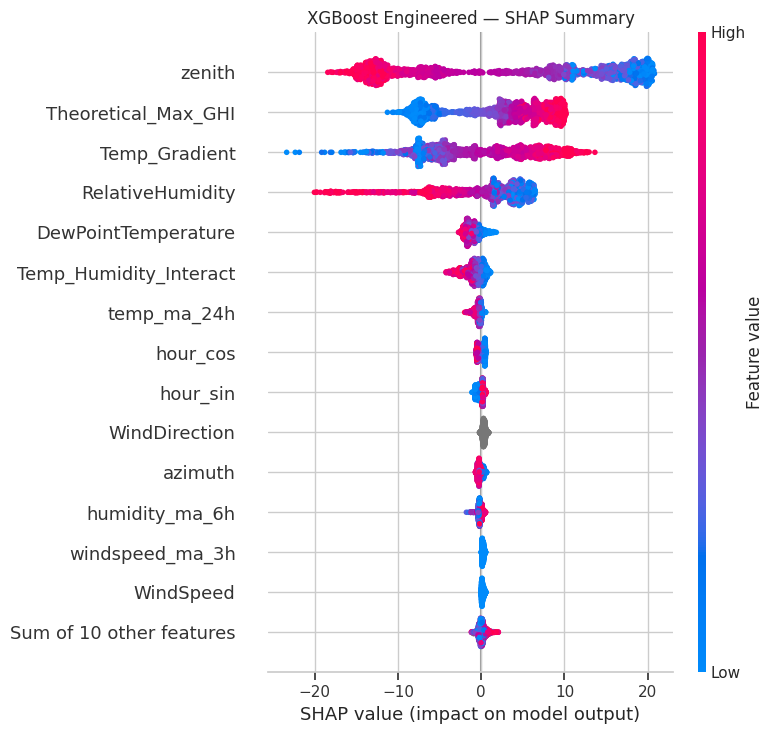

In [27]:
import shap
import matplotlib.pyplot as plt

model    = model_configs["XGBoost"]["Engineered"]
X_tr, y_tr, X_te, y_te, gr = feature_sets["Engineered"]

explainer   = shap.TreeExplainer(model)
shap_values = explainer(X_te)

# summary (beeswarm)
fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("XGBoost Engineered — SHAP Summary", fontsize=12)
plt.tight_layout()
plt.savefig("summary_xgb_engineered.png", dpi=150)
plt.show()

### Lean Mode Optimization

In [33]:
print("Running DEEP tuning for lean XGBoost (100 trials)...")

selected_features = [
    'RelativeHumidity',
    'WindSpeed',
    'Theoretical_Max_GHI',
    'zenith',
    'Temp_Gradient',
    'hour_sin',
    'hour_cos',
    'ApparentTemperature',
    'DewPointTemperature'
]

print(f"Filtering dataset down to the top {len(selected_features)} essential features...")

X_train_final = X_train_eng[selected_features]
X_test_final = X_test_eng[selected_features]

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'tree_method': 'hist',
        'random_state': 42
    }

    tscv = TimeSeriesSplit(n_splits=3)
    rmse_scores = []

    for train_idx, val_idx in tscv.split(X_train):
        model = xgb.XGBRegressor(**param)
        model.fit(X_train_final.iloc[train_idx], y_train.iloc[train_idx])
        preds = model.predict(X_train_final.iloc[val_idx])
        rmse_scores.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], preds)))

    mean_rmse = np.mean(rmse_scores)

    # Print trial progress
    print(f"Trial {trial.number}: RMSE={mean_rmse:.4f}")

    return mean_rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

print("\nBest Hyperparameters Found:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")


Running DEEP tuning for lean XGBoost (100 trials)...
Filtering dataset down to the top 9 essential features...
Trial 0: RMSE=13.9866
Trial 1: RMSE=10.0438
Trial 2: RMSE=9.8050
Trial 3: RMSE=10.4127
Trial 4: RMSE=10.6231
Trial 5: RMSE=9.9691
Trial 6: RMSE=9.7678
Trial 7: RMSE=10.0159
Trial 8: RMSE=9.9640
Trial 9: RMSE=10.0378
Trial 10: RMSE=13.7276
Trial 11: RMSE=10.0309
Trial 12: RMSE=10.5029
Trial 13: RMSE=9.9406
Trial 14: RMSE=11.2893
Trial 15: RMSE=13.0468
Trial 16: RMSE=10.0280
Trial 17: RMSE=10.7035
Trial 18: RMSE=10.0157
Trial 19: RMSE=11.1270
Trial 20: RMSE=9.9774
Trial 21: RMSE=9.9653
Trial 22: RMSE=9.9059
Trial 23: RMSE=10.0023
Trial 24: RMSE=10.2397
Trial 25: RMSE=9.9590
Trial 26: RMSE=9.8106
Trial 27: RMSE=12.1585
Trial 28: RMSE=13.7474
Trial 29: RMSE=19.0841
Trial 30: RMSE=11.5573
Trial 31: RMSE=9.9516
Trial 32: RMSE=10.0371
Trial 33: RMSE=10.6006
Trial 34: RMSE=9.9319
Trial 35: RMSE=9.8056
Trial 36: RMSE=9.8866
Trial 37: RMSE=9.8688
Trial 38: RMSE=14.2126
Trial 39: RMSE=9.

### Ultimate Lean Model Training

The final feature set is decided using feature importance (gain), SHAP, recursive feature elimination and trail and error

In [35]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

xgb_lean_params = {
    "n_estimators": 141,
    "max_depth": 4,
    "learning_rate": 0.031097,
    "subsample": 0.728633,
    "colsample_bytree": 0.952282,
    "min_child_weight": 2,
    "reg_alpha": 1.050428e-07,
    "reg_lambda": 0.885818,
    "tree_method": "hist"
}

print("Training the Ultimate Lean XGBoost model...")
final_xgb_model = xgb.XGBRegressor(**xgb_lean_params, random_state=42)
final_xgb_model.fit(X_train_final, y_train_eng)

# Predict
final_preds = np.maximum(0, final_xgb_model.predict(X_test_final))

# Calculate
r2 = r2_score(y_test_eng, final_preds)
rmse = np.sqrt(mean_squared_error(y_test_eng, final_preds))
mae = mean_absolute_error(y_test_eng, final_preds)
nrmse_range = (rmse / global_range_eng) * 100 if global_range_eng != 0 else 0

# Results
print(f"\nUltimate Lean Model Results ({len(selected_features)} Features)")
print(f"R-Square:      {r2:.4f}")
print(f"RMSE:          {rmse:.3f} kW")
print(f"MAE:           {mae:.3f} kW")
print(f"NRMSE (Range): {nrmse_range:.2f}%")

Training the Ultimate Lean XGBoost model...

Ultimate Lean Model Results (9 Features)
R-Square:      0.8874
RMSE:          9.389 kW
MAE:           6.761 kW
NRMSE (Range): 10.83%


### Performance Comparison Visuals

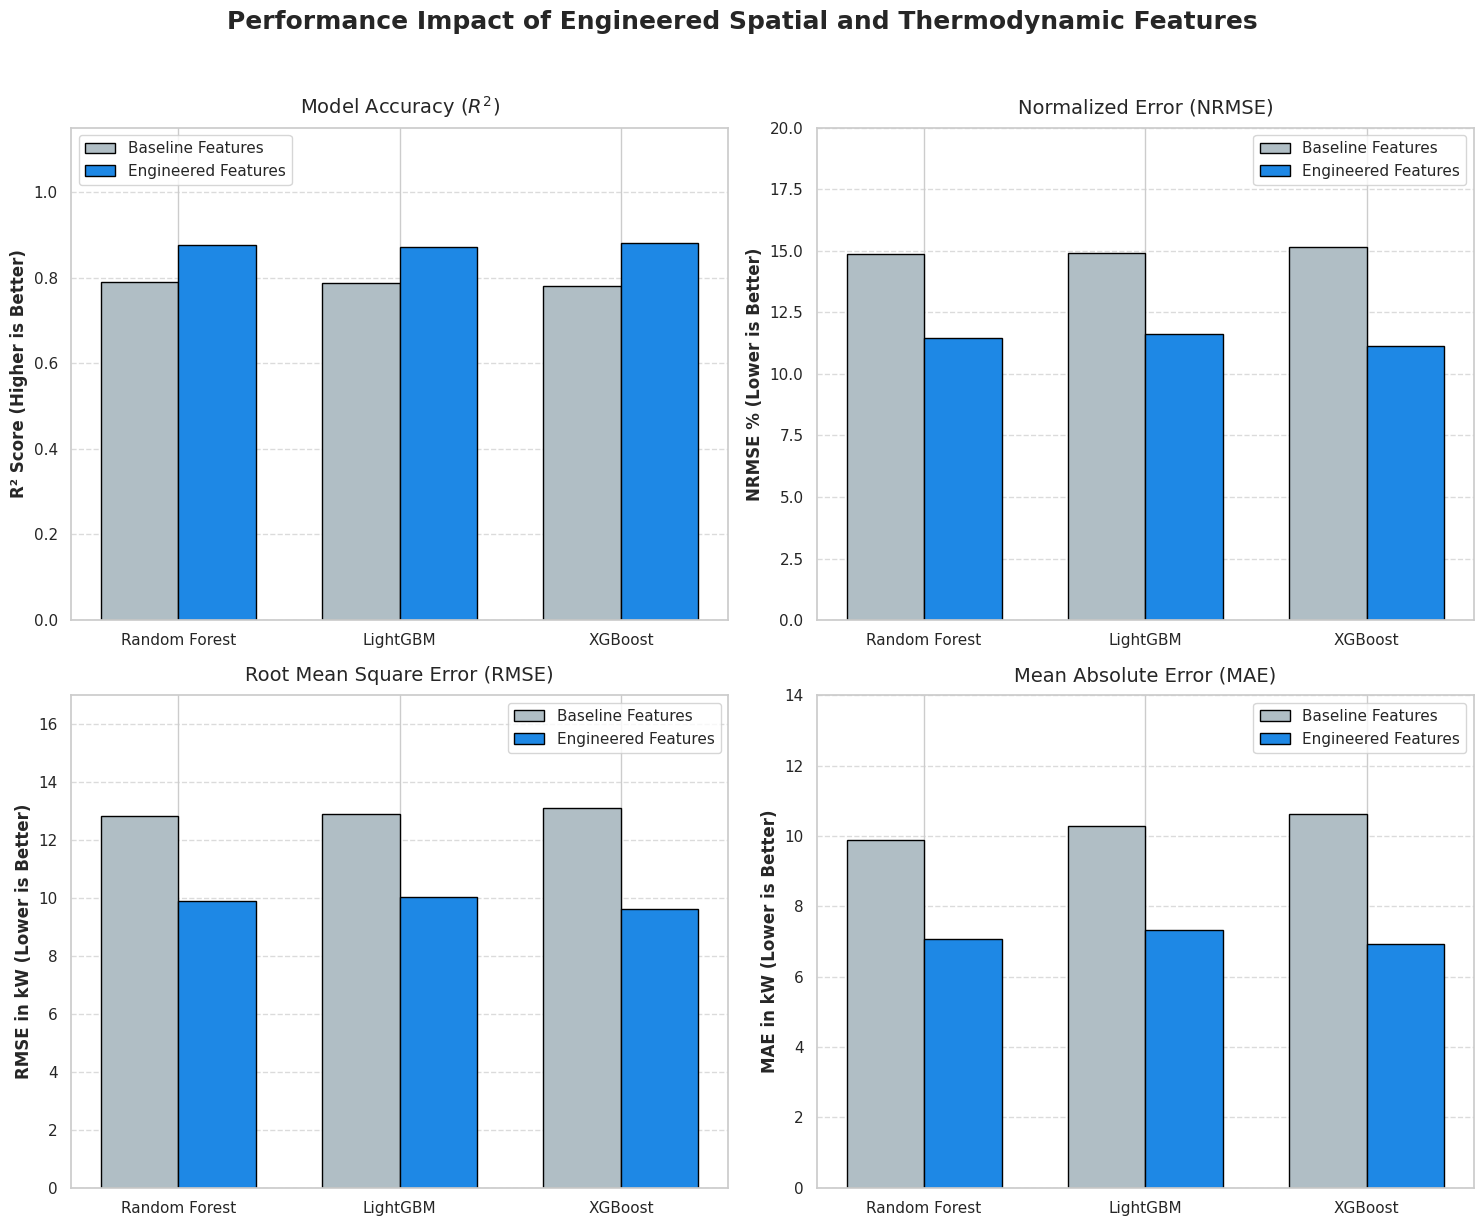

In [36]:
models = ['Random Forest', 'LightGBM', 'XGBoost']

# Metrics Values

r2_baseline = [0.7884, 0.7865, 0.7790]
r2_engineered = [0.8749, 0.8711, 0.8817]

nrmse_baseline = [14.85, 14.91, 15.17]
nrmse_engineered = [11.44, 11.61, 11.13]

rmse_baseline = [12.845, 12.900, 13.125]
rmse_engineered = [9.896, 10.044, 9.623]

mae_baseline = [9.893, 10.275, 10.619]
mae_engineered = [7.076, 7.325, 6.920]

x = np.arange(len(models))
width = 0.35

fig, axs = plt.subplots(2, 2, figsize=(15, 12))

base_color = '#B0BEC5'
eng_color = '#1E88E5'
edge = 'black'

# R2 comparison
axs[0, 0].bar(x - width/2, r2_baseline, width,
              label='Baseline Features', color=base_color, edgecolor=edge)
axs[0, 0].bar(x + width/2, r2_engineered, width,
              label='Engineered Features', color=eng_color, edgecolor=edge)
axs[0, 0].set_ylabel('R² Score (Higher is Better)', fontsize=12, weight='bold')
axs[0, 0].set_title('Model Accuracy ($R^2$)', fontsize=14, pad=10)
axs[0, 0].set_xticks(x)
axs[0, 0].set_xticklabels(models, fontsize=11)
axs[0, 0].set_ylim(0, 1.15)
axs[0, 0].legend(loc='upper left')
axs[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# NRMSE comparison
axs[0, 1].bar(x - width/2, nrmse_baseline, width,
              label='Baseline Features', color=base_color, edgecolor=edge)
axs[0, 1].bar(x + width/2, nrmse_engineered, width,
              label='Engineered Features', color=eng_color, edgecolor=edge)
axs[0, 1].set_ylabel('NRMSE % (Lower is Better)', fontsize=12, weight='bold')
axs[0, 1].set_title('Normalized Error (NRMSE)', fontsize=14, pad=10)
axs[0, 1].set_xticks(x)
axs[0, 1].set_xticklabels(models, fontsize=11)
axs[0, 1].set_ylim(0, 20)
axs[0, 1].legend(loc='upper right')
axs[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

# RMSE comparison
axs[1, 0].bar(x - width/2, rmse_baseline, width,
              label='Baseline Features', color=base_color, edgecolor=edge)
axs[1, 0].bar(x + width/2, rmse_engineered, width,
              label='Engineered Features', color=eng_color, edgecolor=edge)
axs[1, 0].set_ylabel('RMSE in kW (Lower is Better)', fontsize=12, weight='bold')
axs[1, 0].set_title('Root Mean Square Error (RMSE)', fontsize=14, pad=10)
axs[1, 0].set_xticks(x)
axs[1, 0].set_xticklabels(models, fontsize=11)
axs[1, 0].set_ylim(0, 17)
axs[1, 0].legend(loc='upper right')
axs[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# MAE comparison
axs[1, 1].bar(x - width/2, mae_baseline, width,
              label='Baseline Features', color=base_color, edgecolor=edge)
axs[1, 1].bar(x + width/2, mae_engineered, width,
              label='Engineered Features', color=eng_color, edgecolor=edge)
axs[1, 1].set_ylabel('MAE in kW (Lower is Better)', fontsize=12, weight='bold')
axs[1, 1].set_title('Mean Absolute Error (MAE)', fontsize=14, pad=10)
axs[1, 1].set_xticks(x)
axs[1, 1].set_xticklabels(models, fontsize=11)
axs[1, 1].set_ylim(0, 14)
axs[1, 1].legend(loc='upper right')
axs[1, 1].grid(axis='y', linestyle='--', alpha=0.7)

# Title and spacing
plt.suptitle(
    'Performance Impact of Engineered Spatial and Thermodynamic Features',
    fontsize=18,
    weight='bold',
    y=1.02
)

plt.tight_layout()

# Save
plt.savefig('Comprehensive_Model_Performance.png', dpi=300, bbox_inches='tight')

plt.show()

## Multisite Validation

In [39]:
unique_sites = sorted(df['SiteKey'].dropna().unique())

all_site_results = {}

for site_id in unique_sites:
    print()
    print(f"Processing Site {site_id}")

    # Isolate
    target_site_df = df[(df['SiteKey'] == site_id)].copy()
    if target_site_df.empty:
        print(f"No data found for Site {site_id}. Skipping...")
        continue

    target_site_df = target_site_df.sort_values('Timestamp')

    # Resample
    target_site_df.set_index('Timestamp', inplace=True)
    hourly_df = target_site_df.resample('1h').mean()
    hourly_df['SolarGeneration'] = hourly_df['SolarGeneration'] * 4
    hourly_df.reset_index(inplace=True)

    # Interpolate
    weather_cols = ['ApparentTemperature', 'AirTemperature', 'RelativeHumidity', 'WindSpeed']
    hourly_df[weather_cols] = hourly_df[weather_cols].interpolate(method='linear').ffill().bfill()

    # Lean Feature Engineering
    print(f"Engineering features for Site {site_id}...")

    tz = 'Australia/Melbourne'
    lat, lon = hourly_df['lat'].iloc[0], hourly_df['Lon'].iloc[0]
    location = pvlib.location.Location(lat, lon, tz=tz)
    times = pd.DatetimeIndex(hourly_df['Timestamp'])

    if times.tz is None:
        times = times.tz_localize(tz, ambiguous='NaT', nonexistent='NaT')

    hourly_df['Theoretical_Max_GHI'] = location.get_clearsky(times)['ghi'].values
    solar_position = location.get_solarposition(times)
    hourly_df['zenith'] = solar_position['zenith'].values

    hourly_df['Temp_Gradient'] = hourly_df['AirTemperature'].diff()

    hourly_df['hour_sin'] = np.sin(2 * np.pi * hourly_df['Timestamp'].dt.hour/24)
    hourly_df['hour_cos'] = np.cos(2 * np.pi * hourly_df['Timestamp'].dt.hour/24)

    df_final = hourly_df.iloc[LAG_STEPS:].reset_index(drop=True)
    df_final = df_final.dropna(subset=['SolarGeneration'])

    features = [
        'RelativeHumidity', 'WindSpeed',
        'Theoretical_Max_GHI', 'zenith',
        'Temp_Gradient',
        'hour_sin', 'hour_cos', 'ApparentTemperature','DewPointTemperature'
    ]

    X = df_final[features]
    y = df_final['SolarGeneration']

    # 5. Chronological Split 80/20
    split = int(len(df_final) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    print(f"Data processed! Training on {len(X_train)} rows.")
    print(f"Running DEEP tuning for XGBoost (20 trials) for Site {site_id}...")

    # 6. Define objective
    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
            'tree_method': 'hist',
            'device': 'cuda',
            'random_state': 42
        }

        tscv = TimeSeriesSplit(n_splits=3)
        rmse_scores = []

        for train_idx, val_idx in tscv.split(X_train):
            model = xgb.XGBRegressor(**param)
            model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
            preds = model.predict(X_train.iloc[val_idx])
            rmse_scores.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], preds)))

        mean_rmse = np.mean(rmse_scores)
        print(f"  Site {site_id} | Trial {trial.number}: RMSE={mean_rmse:.4f}")
        return mean_rmse

    # 7. Run Optuna
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=20)

    print(f"\nBest Hyperparameters Found for Site {site_id}:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")
    print("Training final deep-optimized model...")
    best_model = xgb.XGBRegressor(**study.best_params, tree_method='hist',device='cuda', random_state=42)
    best_model.fit(X_train, y_train)

    # 9. Predictions and Evaluation
    final_preds = np.maximum(0, best_model.predict(X_test))

    mae = mean_absolute_error(y_test, final_preds)
    rmse = np.sqrt(mean_squared_error(y_test, final_preds))
    r2 = r2_score(y_test, final_preds)

    y_max = y_test.max()
    y_min = y_test.min()
    y_mean = y_test.mean()

    nrmse_range = (rmse / (y_max - y_min)) * 100 if (y_max - y_min) != 0 else 0
    nrmse_mean = (rmse / y_mean) * 100 if y_mean != 0 else 0

    print("\n" + "="*50)
    print(f"RESULTS: DAY-AHEAD FORECAST - SITE {site_id}")
    print("="*50)
    print(f"MAE:  {mae:.3f} kW")
    print(f"RMSE: {rmse:.3f} kW")
    print(f"R^2:  {r2:.4f}")
    print("-" * 50)
    print(f"Site {site_id} Max Gen: {y_max:.2f} kW")
    print(f"NRMSE (Range):   {nrmse_range:.2f}%")
    print(f"NRMSE (Mean):    {nrmse_mean:.2f}%")
    print("="*50)

    # 10. Store
    all_site_results[site_id] = {
        'best_params': study.best_params,
        'metrics': {'mae': mae, 'rmse': rmse, 'r2': r2},
        'model': best_model
    }

print("\nAll 42 sites processed successfully!")


Processing Site 1
Engineering features for Site 1...
Data processed! Training on 8184 rows.
Running DEEP tuning for XGBoost (20 trials) for Site 1...
  Site 1 | Trial 0: RMSE=10.2545
  Site 1 | Trial 1: RMSE=10.0501
  Site 1 | Trial 2: RMSE=10.3620
  Site 1 | Trial 3: RMSE=10.4630
  Site 1 | Trial 4: RMSE=12.3550
  Site 1 | Trial 5: RMSE=11.5743
  Site 1 | Trial 6: RMSE=10.3982
  Site 1 | Trial 7: RMSE=13.1427
  Site 1 | Trial 8: RMSE=10.1425
  Site 1 | Trial 9: RMSE=10.9680
  Site 1 | Trial 10: RMSE=13.5283
  Site 1 | Trial 11: RMSE=10.0219
  Site 1 | Trial 12: RMSE=9.9835
  Site 1 | Trial 13: RMSE=9.9763
  Site 1 | Trial 14: RMSE=9.9995
  Site 1 | Trial 15: RMSE=9.9088
  Site 1 | Trial 16: RMSE=9.8613
  Site 1 | Trial 17: RMSE=9.9352
  Site 1 | Trial 18: RMSE=9.9448
  Site 1 | Trial 19: RMSE=9.8414

Best Hyperparameters Found for Site 1:
  n_estimators: 231
  max_depth: 4
  learning_rate: 0.013701890173431671
  subsample: 0.6671478428396639
  colsample_bytree: 0.9270765126900148
  m

#### Save Results

In [40]:
import pickle

save_path = '/content/drive/MyDrive/UNISOLAR_Data/all_site_results_optimized.pkl'

with open(save_path, 'wb') as file:
    pickle.dump(all_site_results, file)

print(f"Success! All 42 models and metrics are safely backed up to: {save_path}")

Success! All 42 models and metrics are safely backed up to: /content/drive/MyDrive/UNISOLAR_Data/all_site_results_optimized.pkl


In [41]:
print(all_site_results)

{np.int64(1): {'best_params': {'n_estimators': 231, 'max_depth': 4, 'learning_rate': 0.013701890173431671, 'subsample': 0.6671478428396639, 'colsample_bytree': 0.9270765126900148, 'min_child_weight': 6, 'reg_alpha': 4.680274907206891e-07, 'reg_lambda': 2.6230720068250948e-05}, 'metrics': {'mae': 7.130341240024552, 'rmse': np.float64(9.71905761707196), 'r2': 0.8793522450972221}, 'model': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9270765126900148, device='cuda',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.013701890173431671,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
  

## Train on Best hyperparameters and evaluate

In [42]:
# Extract the Hyperparameters
params_list = []
metrics_list = []

for site_id, data in all_site_results.items():
    site_int = int(site_id)

    site_params = data['best_params'].copy()
    site_params['SiteKey'] = site_int
    params_list.append(site_params)

    site_metrics = data['metrics'].copy()
    site_metrics['SiteKey'] = site_int
    metrics_list.append(site_metrics)

df_params = pd.DataFrame(params_list)
df_metrics = pd.DataFrame(metrics_list)

site_stats_list = []
unique_sites = df['SiteKey'].dropna().unique()

for site_id in unique_sites:
    # Isolate
    temp_df = df[df['SiteKey'] == site_id].copy()
    if temp_df.empty:
        continue

    # Resample
    temp_df.set_index('Timestamp', inplace=True)
    temp_hourly = temp_df.resample('1h').mean()
    temp_hourly['SolarGeneration'] = temp_hourly['SolarGeneration'] * 4

    # Max and min
    site_max = temp_hourly['SolarGeneration'].max()
    site_min = temp_hourly['SolarGeneration'].min()

    site_stats_list.append({
        'SiteKey': int(site_id),
        'Max_Generation': site_max,
        'Min_Generation': site_min
    })

df_stats = pd.DataFrame(site_stats_list)

# NRMSE
df_metrics = df_metrics.merge(df_stats, on='SiteKey', how='inner')

df_metrics['Generation_Range'] = df_metrics['Max_Generation'] - df_metrics['Min_Generation']

df_metrics['NRMSE_Range_%'] = np.where(
    df_metrics['Generation_Range'] != 0,
    (df_metrics['rmse'] / df_metrics['Generation_Range']) * 100,
    0
)

# Display
df_params = df_params[['SiteKey'] + [col for col in df_params.columns if col != 'SiteKey']]
df_metrics = df_metrics[['SiteKey', 'mae', 'rmse', 'r2', 'Max_Generation', 'NRMSE_Range_%']]

print("Final Test Results")
display(df_metrics.head(10))

Final Test Results


,SiteKey,mae,rmse,r2,Max_Generation,NRMSE_Range_%
0,1,7.130341,9.719058,0.879352,87.112000,11.208951
1,2,6.084014,8.766085,0.874235,74.250000,11.870122
2,3,4.408131,6.247342,0.863934,53.625000,11.740255
3,4,0.537855,0.760884,0.879396,7.789062,10.306149
4,5,0.608785,0.871605,0.850163,7.796875,11.793381
5,6,7.707422,11.135389,0.904025,114.937500,9.722577
6,7,5.817045,7.964585,0.837597,64.125000,12.517972
7,8,7.508577,11.216692,0.893966,107.718750,10.452363
8,9,0.722172,0.962177,0.843385,8.046875,12.582612
9,10,2.592114,3.553831,0.881970,31.000000,11.616863


In [43]:
print("Hyperparameters")
display(df_params.head(10))

Hyperparameters


,SiteKey,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_alpha,reg_lambda
0,1,231,4,0.013702,0.667148,0.927077,6,4.680275e-07,0.000026
1,2,836,10,0.005795,0.505290,0.988751,9,7.639734e-06,0.000002
2,3,445,7,0.007564,0.823397,0.654643,6,5.952507e-07,0.001891
3,4,858,4,0.008533,0.549796,0.686698,9,5.208723e-02,0.062725
4,5,656,7,0.008219,0.634378,0.836480,8,4.836771e-03,0.000161
5,6,991,5,0.006752,0.895916,0.797836,8,3.027187e-03,0.000024
6,7,846,8,0.004901,0.671543,0.501555,10,1.062211e-06,0.001695
7,8,562,5,0.009020,0.568715,0.711027,8,9.623374e-02,0.000007
8,9,480,4,0.014967,0.579900,0.914433,10,9.174095e-01,0.000154
9,10,873,4,0.008789,0.593522,0.676628,7,2.852085e-07,0.945292


In [44]:
from google.colab import files

df_params.to_csv('Optimized_Hyperparameters_By_Site.csv', index=False)
df_metrics.to_csv('Final_Test_Results_By_Site.csv', index=False)

files.download('Optimized_Hyperparameters_By_Site.csv')
files.download('Final_Test_Results_By_Site.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
dh=df_metrics.drop(columns=['SiteKey'])
dh = dh.iloc[1:]

# calculate average of all columns
column_averages = dh.mean()

print(column_averages)


mae                6.580478
rmse               9.203111
r2                 0.818901
Max_Generation    75.065168
NRMSE_Range_%     12.425624
dtype: float64
